# Explore a trained GPT-Addition model

**Reference:** [See a GPT's internals animated in 3D](https://bbycroft.net/llm)

This notebook loads a trained checkpoint and explores it: the data format, exact-match
accuracy, failure modes, and attention patterns.

Training itself happens in the terminal, not here:

```bash
scripts/train.sh                    # forward, unpadded (default — hardest)
scripts/train.sh --reverse --pad    # ones-digit-first, fixed length (easiest)
scripts/train_parallel.sh           # both at once
```

Set the three knobs in the setup cell to match the run you want to inspect.

In [10]:
import math, random, glob

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

from src.model      import GPT, GPTConfig
from src.data       import make_problem, encode, decode, VOCAB, VOCAB_SIZE, stoi, itos
from src.evaluate   import evaluate
from src.checkpoint import run_tag

device = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)

# ── which trained run to explore ──────────────────────────────────────────────
ndigits   = 3
reverse_c = False# ones digit first
pad_c     = False   # answer not zero-padded

print(f'Device: {device}   run tag: {run_tag(ndigits, reverse_c, pad_c)}')

Device: mps   run tag: addition_3digit_fwd_nopad


## 1. Data

Problems are strings `"A+B=C"`. Operands have no leading zeros; the answer is reversed
when `reverse_c=True` and zero-padded to `ndigits+1` digits when `pad_c=True`.

In [11]:
print(f'Vocab ({VOCAB_SIZE} tokens): {VOCAB!r}')
print(f'Token map: {stoi}')
print()
print('Example problems (a + b = c, encoded as string):')
print(f'  {"string":20s}  {"a":>5}  {"b":>5}  {"c":>5}  answer-as-written')
print('  ' + '-'*60)
for _ in range(12):
    s, a, b, c = make_problem(ndigits, reverse_c, pad_c)
    ans = s[s.index('=')+1:]
    print(f'  {s:20s}  {a:5d}  {b:5d}  {c:5d}  {ans}')

Vocab (12 tokens): '0123456789+='
Token map: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '+': 10, '=': 11}

Example problems (a + b = c, encoded as string):
  string                    a      b      c  answer-as-written
  ------------------------------------------------------------
  586+445=1031            586    445   1031  1031
  171+973=1144            171    973   1144  1144
  213+981=1194            213    981   1194  1194
  882+168=1050            882    168   1050  1050
  994+647=1641            994    647   1641  1641
  563+78=641              563     78    641  641
  346+379=725             346    379    725  725
  28+943=971               28    943    971  971
  603+242=845             603    242    845  845
  252+363=615             252    363    615  615
  558+826=1384            558    826   1384  1384
  855+475=1330            855    475   1330  1330


In [12]:
# How a problem gets tokenised and where the loss mask sits
s, a, b, c = make_problem(ndigits, reverse_c, pad_c)
tokens = encode(s)
x_tok  = tokens[:-1]
y_tok  = tokens[1:]
mask_end = tokens.index(stoi['='])  # everything before '=' is masked in y

print(f'Problem string : {s!r}  (len={len(s)})')
print(f'x (input)      : {x_tok}')
print(f'y (target)     : {y_tok}')
print(f'y after masking: {[-1]*mask_end + y_tok[mask_end:]}')
print()
print('Position breakdown:')
for i, (xi, yi) in enumerate(zip(x_tok, y_tok)):
    masked = '(masked)' if i < mask_end else '<-- LOSS HERE'
    print(f'  pos {i:2d}: x={itos[xi]!r:2s}  y={itos[yi]!r:2s}  {masked}')

Problem string : '575+904=1479'  (len=12)
x (input)      : [5, 7, 5, 10, 9, 0, 4, 11, 1, 4, 7]
y (target)     : [7, 5, 10, 9, 0, 4, 11, 1, 4, 7, 9]
y after masking: [-1, -1, -1, -1, -1, -1, -1, 1, 4, 7, 9]

Position breakdown:
  pos  0: x='5'  y='7'  (masked)
  pos  1: x='7'  y='5'  (masked)
  pos  2: x='5'  y='+'  (masked)
  pos  3: x='+'  y='9'  (masked)
  pos  4: x='9'  y='0'  (masked)
  pos  5: x='0'  y='4'  (masked)
  pos  6: x='4'  y='='  (masked)
  pos  7: x='='  y='1'  <-- LOSS HERE
  pos  8: x='1'  y='4'  <-- LOSS HERE
  pos  9: x='4'  y='7'  <-- LOSS HERE
  pos 10: x='7'  y='9'  <-- LOSS HERE


## 2. Load a trained model

Loads the newest checkpoint matching the knobs above. The checkpoint stores the model
config and the full run config, so nothing else needs to be specified.

In [13]:
print('All checkpoints on disk:')
for f in sorted(glob.glob('checkpoints/*.pt')):
    print('  ', f)

tag   = run_tag(ndigits, reverse_c, pad_c)
files = sorted(glob.glob(f'checkpoints/{tag}_epoch*.pt'))
assert files, f'No checkpoint for tag {tag!r} — train one first (see the intro cell)'

path = files[-1]
with torch.serialization.safe_globals([GPTConfig]):
    state = torch.load(path, map_location=device, weights_only=True)

gpt_cfg = state['gpt_cfg']
model   = GPT(gpt_cfg).to(device)
model.load_state_dict(state['model'])
model.eval()

rc = state['run_config']
print(f'\nLoaded {path}  (step {state["step"]:,})')
print('run_config:', {k: rc.get(k) for k in ('ndigits', 'c_order', 'pad_c', 'n_params', 'started_at')})

All checkpoints on disk:
   checkpoints/addition_3digit_epoch0007.pt
   checkpoints/addition_3digit_epoch0008.pt
   checkpoints/addition_3digit_epoch0009.pt
   checkpoints/addition_3digit_fwd_epoch0005.pt
   checkpoints/addition_3digit_fwd_epoch0006.pt
   checkpoints/addition_3digit_fwd_epoch0007.pt
   checkpoints/addition_3digit_fwd_nopad_epoch0010.pt
   checkpoints/addition_3digit_fwd_nopad_epoch0011.pt
   checkpoints/addition_3digit_fwd_nopad_epoch0012.pt
   checkpoints/addition_3digit_rev_epoch0003.pt
   checkpoints/addition_3digit_rev_epoch0004.pt
   checkpoints/addition_3digit_rev_epoch0005.pt
   checkpoints/addition_3digit_rev_nopad_epoch0005.pt
   checkpoints/addition_3digit_rev_nopad_epoch0006.pt
   checkpoints/addition_3digit_rev_nopad_epoch0007.pt

Loaded checkpoints/addition_3digit_fwd_nopad_epoch0012.pt  (step 59,999)
run_config: {'ndigits': 3, 'c_order': 'forward', 'pad_c': False, 'n_params': 201536, 'started_at': '2026-06-12T00:19:48'}


## 3. Evaluation

Exact-match accuracy over random problems, hand-picked examples, and accuracy by
operand magnitude.

In [14]:
acc = evaluate(model, ndigits=ndigits, n_samples=1_000, device=device,
               reverse_c=reverse_c, pad_c=pad_c)
order = 'reversed' if reverse_c else 'forward'
print(f'Accuracy ({order}, {"padded" if pad_c else "unpadded"}) '
      f'over 1000 random {ndigits}-digit problems: {acc*100:.1f}%')

Accuracy (forward, unpadded) over 1000 random 3-digit problems: 99.3%


In [15]:
# Try specific examples
def add_with_gpt(a: int, b: int) -> tuple[int | None, str]:
    """Ask the model for a+b. Returns (parsed answer or None, raw generated string)."""
    question = f'{a}+{b}='
    n_tokens = (ndigits + 1) if pad_c else len(str(a + b))  # without an EOS token the
    x = torch.tensor(encode(question), dtype=torch.long,    # answer length is given
                     device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(x, max_new_tokens=n_tokens, greedy=True)
    raw = decode(out[0, len(question):].tolist())
    try:
        return int(raw[::-1] if reverse_c else raw), raw
    except ValueError:
        return None, raw

test_cases = [
    (1, 1), (9, 9), (123, 456), (999, 1), (500, 500),
    (999, 999), (42, 58), (100, 200), (0, 0),
]
print(f'  {"a":>6}  {"b":>6}  {"expected":>8}  {"got":>8}  {"raw":>8}  ok?')
print('  ' + '-'*55)
for a, b in test_cases:
    expected   = a + b
    got, raw   = add_with_gpt(a, b)
    ok         = 'ok' if got == expected else 'WRONG'
    print(f'  {a:6d}  {b:6d}  {expected:8d}  {str(got):>8s}  {raw:>8s}  {ok}')

       a       b  expected       got       raw  ok?
  -------------------------------------------------------
       1       1         2         2         2  ok
       9       9        18        11        11  WRONG
     123     456       579       579       579  ok
     999       1      1000      9000      9000  WRONG
     500     500      1000      1000      1000  ok
     999     999      1998      1998      1998  ok
      42      58       100       100       100  ok
     100     200       300       300       300  ok
       0       0         0         0         0  ok


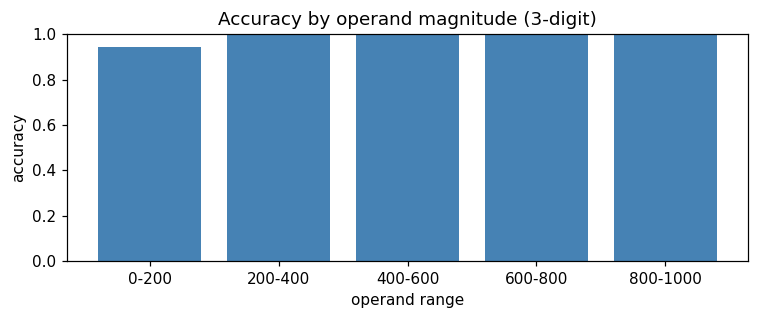

In [16]:
# Does accuracy vary by magnitude of the operands?
buckets = 5
bucket_size = 10**ndigits // buckets
results = []

for bucket in range(buckets):
    lo = bucket * bucket_size
    hi = lo + bucket_size
    correct, total = 0, 200
    for _ in range(total):
        a = random.randint(lo, hi - 1)
        b = random.randint(lo, hi - 1)
        got, _ = add_with_gpt(a, b)
        correct += int(got == a + b)
    results.append((f'{lo}-{hi}', correct / total))

labels, accs = zip(*results)
plt.figure(figsize=(7, 3))
plt.bar(labels, accs, color='steelblue')
plt.ylim(0, 1); plt.ylabel('accuracy'); plt.xlabel('operand range')
plt.title(f'Accuracy by operand magnitude ({ndigits}-digit)')
plt.tight_layout(); plt.show()

In [35]:
add_with_gpt(999,9992)

(19120, '19120')

## 4. Attention patterns

For each layer/head, which input positions does the model attend to when predicting
each output digit? A well-trained model should show answer positions attending back to
the corresponding digit columns of the operands.

In [8]:
def get_attention_maps(problem_str: str):
    """
    Run one forward pass on `problem_str` (full sequence, including answer)
    and return a list of (n_head, T, T) attention tensors, one per layer.
    """
    tokens = encode(problem_str)
    x = torch.tensor(tokens[:-1], dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        model(x)  # triggers _last_attn capture in each CausalSelfAttention
    return [block.attn._last_attn[0].cpu() for block in model.transformer.h]


# Pick a concrete problem to inspect — formatted exactly like the training data
a_ex, b_ex = 123, 456
c_ex   = a_ex + b_ex
c_str  = str(c_ex).zfill(ndigits + 1) if pad_c else str(c_ex)
c_out  = c_str[::-1] if reverse_c else c_str
prob_str = f'{a_ex}+{b_ex}={c_out}'
print(f'Problem: {prob_str}  ({a_ex} + {b_ex} = {c_ex}, answer as written: {c_out!r})')

attn_maps = get_attention_maps(prob_str)
seq_chars = list(prob_str[:-1])  # x chars
print(f'Sequence characters: {seq_chars}')
print(f'Captured {len(attn_maps)} layers, each shape: {list(attn_maps[0].shape)}')

Problem: 123+456=975  (123 + 456 = 579, answer as written: '975')
Sequence characters: ['1', '2', '3', '+', '4', '5', '6', '=', '9', '7']
Captured 4 layers, each shape: [4, 10, 10]


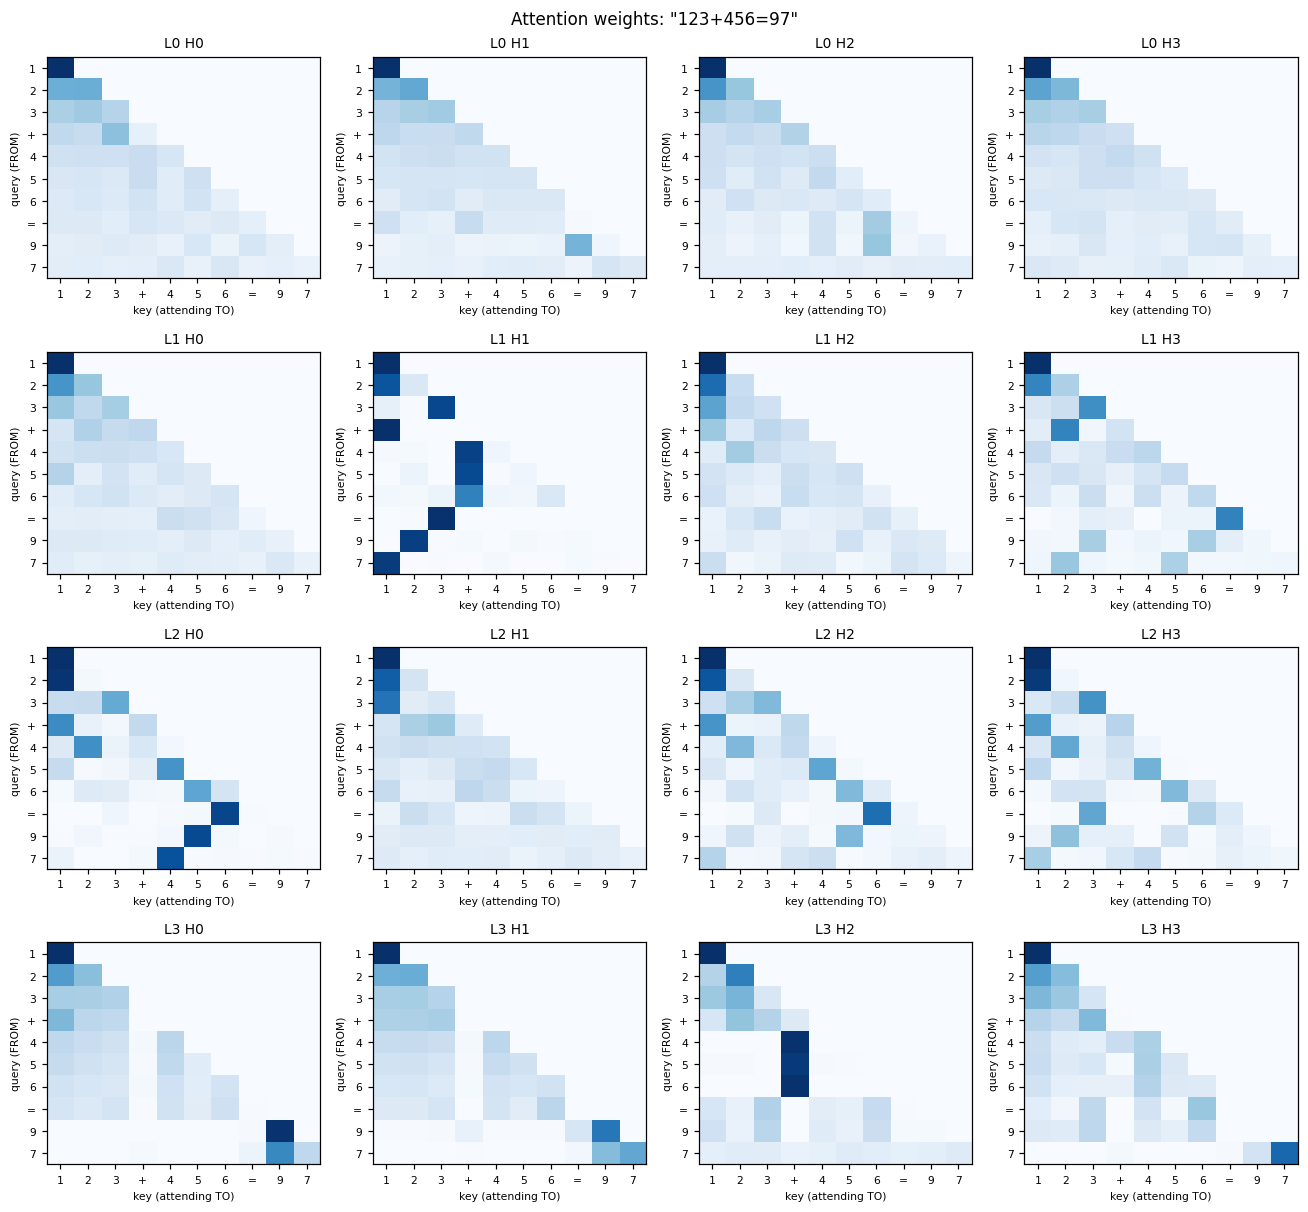

In [9]:
n_layers = len(attn_maps)
n_heads  = attn_maps[0].shape[0]
T        = attn_maps[0].shape[-1]

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 2.8 * n_layers))

for layer_idx, attn in enumerate(attn_maps):
    for head_idx in range(n_heads):
        ax = axes[layer_idx][head_idx]
        data = attn[head_idx].numpy()  # (T, T)
        ax.imshow(data, vmin=0, vmax=data.max(), cmap='Blues', aspect='auto')
        ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=9)
        ax.set_xticks(range(T)); ax.set_xticklabels(seq_chars, fontsize=7)
        ax.set_yticks(range(T)); ax.set_yticklabels(seq_chars, fontsize=7)
        ax.set_xlabel('key (attending TO)', fontsize=7)
        ax.set_ylabel('query (FROM)', fontsize=7)

fig.suptitle(f'Attention weights: "{prob_str[:-1]}"', fontsize=11)
plt.tight_layout()
plt.show()

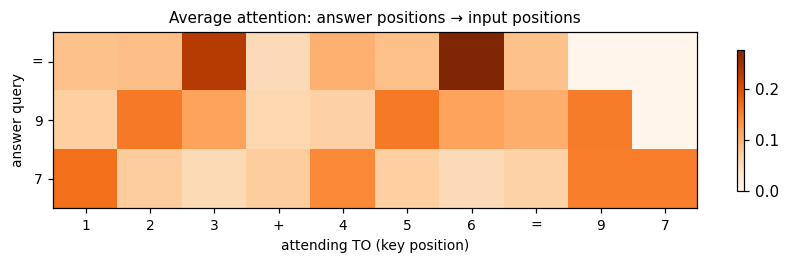

Answer chars : ['9', '7', '5']
(reversed — index 0 = ones digit of the sum)


In [10]:
# Zoom in: average attention from answer positions back to input tokens.
question_len = prob_str.index('=') + 1
T            = attn_maps[0].shape[-1]
avg_attn     = torch.stack(attn_maps).mean(dim=0).mean(dim=0)  # (T, T) over layers & heads

ans_positions = list(range(question_len - 1, T))  # x positions that predict answer tokens
ans_labels    = [seq_chars[p] for p in ans_positions]

fig, ax = plt.subplots(1, 1, figsize=(8, 2.5))
data = avg_attn[ans_positions, :].numpy()
im = ax.imshow(data, cmap='Oranges', aspect='auto', vmin=0)
ax.set_xticks(range(T));                  ax.set_xticklabels(seq_chars, fontsize=9)
ax.set_yticks(range(len(ans_positions))); ax.set_yticklabels(ans_labels, fontsize=9)
ax.set_xlabel('attending TO (key position)', fontsize=9)
ax.set_ylabel('answer query', fontsize=9)
ax.set_title('Average attention: answer positions → input positions', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print('Answer chars :', list(prob_str[question_len:]))
if reverse_c:
    print('(reversed — index 0 = ones digit of the sum)')